In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"D:\Vehicle_Mileage_Project\data\raw\ML Dataset.xlsx"

df = pd.read_excel(path)

In [3]:
df.shape

(64849, 27)

In [4]:
df.isnull().sum()

Vehicle_ID                    1
Manufacturer                  2
Model                         1
Vehicle_Age                 295
Engine_CC                     1
Horsepower                    4
Vehicle_Weight                2
Transmission                  3
Fuel_Type                     1
Ethanol_Blend                 1
Fuel_Price                    1
Trip_Distance_km              3
Average_Speed                 3
Engine_RPM                    5
Tire_Pressure_PSI             2
Maintenance_Status            2
Road_Type                     2
Traffic_Level                 0
Temperature                   2
Humidity                      3
Weather                       4
AC_Usage                      1
Driving_Style                 1
Passengers                    4
CO2_Emission_g_km             1
Fuel_Consumption_L_100km      1
Mileage_km_per_L            334
dtype: int64

In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing

,Missing Values,Percentage
Vehicle_ID,1,0.00
Manufacturer,2,0.00
Model,1,0.00
Vehicle_Age,295,0.45
Engine_CC,1,0.00
Horsepower,4,0.01
Vehicle_Weight,2,0.00
Transmission,3,0.00
Fuel_Type,1,0.00
Ethanol_Blend,1,0.00


In [6]:
df.duplicated().sum()

np.int64(546)

In [7]:
df[df.duplicated()]

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L
2967,V053513,Toyota,Glanza,14.0,1800.0,150.0,880.0,Manual,Petrol,30.0,...,High,29.0,33.0,Fog,No,Smooth,1.0,185.8,4.80,20.82
4077,V019502,Toyota,Glanza,9.0,2000.0,164.0,1612.0,Automatic,Petrol,50.0,...,Low,33.0,39.0,Rain,No,Smooth,4.0,225.2,6.30,15.87
5048,V006351,Hyundai,Venue,4.0,2000.0,165.0,924.0,Automatic,Petrol,50.0,...,Low,32.0,48.0,Rain,Yes,Aggressive,2.0,212.3,5.95,16.82
5452,V056076,Honda,City,8.0,1800.0,147.0,976.0,Manual,Petrol,10.0,...,Medium,36.0,88.0,Clear,Yes,Smooth,3.0,173.7,4.55,22.00
5776,V053492,Maruti,Swift,7.0,1000.0,86.0,1487.0,Automatic,Petrol,30.0,...,High,15.0,89.0,Rain,No,Smooth,4.0,191.2,4.89,20.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64731,V026489,Hyundai,i20,13.0,1500.0,126.0,923.0,Automatic,Petrol,50.0,...,Low,35.0,69.0,Fog,Yes,Normal,2.0,215.4,5.78,17.29
64752,V009693,Toyota,Glanza,3.0,1200.0,105.0,1429.0,Automatic,Petrol,20.0,...,High,16.0,34.0,Fog,Yes,Aggressive,4.0,210.4,6.18,16.18
64764,V035921,Tata,Nexon,1.0,1500.0,128.0,1402.0,Automatic,Petrol,30.0,...,High,39.0,87.0,Fog,Yes,Normal,1.0,216.5,6.41,15.61
64783,V043324,Maruti,Swift,7.0,1200.0,105.0,1404.0,Manual,Petrol,50.0,...,Medium,35.0,58.0,Fog,No,Aggressive,1.0,227.2,6.46,15.48


In [8]:
df.dtypes

Vehicle_ID                      str
Manufacturer                    str
Model                           str
Vehicle_Age                 float64
Engine_CC                   float64
Horsepower                  float64
Vehicle_Weight              float64
Transmission                    str
Fuel_Type                       str
Ethanol_Blend               float64
Fuel_Price                  float64
Trip_Distance_km            float64
Average_Speed               float64
Engine_RPM                  float64
Tire_Pressure_PSI           float64
Maintenance_Status              str
Road_Type                       str
Traffic_Level                   str
Temperature                 float64
Humidity                    float64
Weather                         str
AC_Usage                        str
Driving_Style                   str
Passengers                  float64
CO2_Emission_g_km           float64
Fuel_Consumption_L_100km    float64
Mileage_km_per_L            float64
dtype: object

In [9]:
df.nunique()

Vehicle_ID                  64302
Manufacturer                    5
Model                           8
Vehicle_Age                    16
Engine_CC                       5
Horsepower                     55
Vehicle_Weight                851
Transmission                    2
Fuel_Type                       1
Ethanol_Blend                   5
Fuel_Price                   2501
Trip_Distance_km             5951
Average_Speed                  91
Engine_RPM                   2601
Tire_Pressure_PSI              81
Maintenance_Status              3
Road_Type                       4
Traffic_Level                   3
Temperature                    28
Humidity                       61
Weather                         3
AC_Usage                        2
Driving_Style                   3
Passengers                      5
CO2_Emission_g_km            2002
Fuel_Consumption_L_100km      926
Mileage_km_per_L             2009
dtype: int64

In [10]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("="*50)
    print(col)
    print(df[col].value_counts())

Vehicle_ID
Vehicle_ID
V059128    2
V009012    2
V059218    2
V001098    2
V044332    2
          ..
V062571    1
V038159    1
V000861    1
V015796    1
V056423    1
Name: count, Length: 64302, dtype: int64
Manufacturer
Manufacturer
Tata       13080
Toyota     13028
Maruti     12972
Honda      12905
Hyundai    12862
Name: count, dtype: int64
Model
Model
Glanza    13028
City      12905
Swift      6598
Nexon      6562
Altroz     6519
Venue      6507
Baleno     6374
i20        6355
Name: count, dtype: int64
Transmission
Transmission
Automatic    32512
Manual       32334
Name: count, dtype: int64
Fuel_Type
Fuel_Type
Petrol    64848
Name: count, dtype: int64
Maintenance_Status
Maintenance_Status
Good       21801
Average    21639
Poor       21407
Name: count, dtype: int64
Road_Type
Road_Type
City       16348
Mixed      16212
Rural      16150
Highway    16137
Name: count, dtype: int64
Traffic_Level
Traffic_Level
Low       21649
Medium    21635
High      21565
Name: count, dtype: int64
Weather


C:\Users\sujee\AppData\Local\Temp\ipykernel_19524\1804034625.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle_Age,64554.0,7.485315,4.621749,0.0,3.00,7.00,12.00,15.00
Engine_CC,64848.0,1503.878300,368.608256,1000.0,1200.00,1500.00,1800.00,2000.00
Horsepower,64845.0,125.114427,30.801036,78.0,97.00,125.00,153.00,171.00
Vehicle_Weight,64847.0,1274.431107,245.866585,850.0,1061.00,1274.00,1488.00,1700.00
Ethanol_Blend,64848.0,38.918779,26.522092,10.0,20.00,30.00,50.00,85.00
Fuel_Price,64848.0,102.495828,7.193345,90.0,96.27,102.48,108.72,115.00
Trip_Distance_km,64846.0,302.720027,171.994817,5.0,153.30,302.60,451.60,600.00
Average_Speed,64846.0,64.890695,26.258180,20.0,42.00,65.00,88.00,110.00
Engine_RPM,64844.0,2495.715810,752.938352,1200.0,1841.00,2500.00,3147.00,3800.00
Tire_Pressure_PSI,64847.0,31.996951,2.323987,28.0,30.00,32.00,34.00,36.00


In [12]:
df[df["Vehicle_Age"]<0]

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L


In [13]:
df[df["Horsepower"]<=0]

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L


In [14]:
df[df["Passengers"]<0]

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L


In [15]:
df[df["Mileage_km_per_L"]<=0]

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L


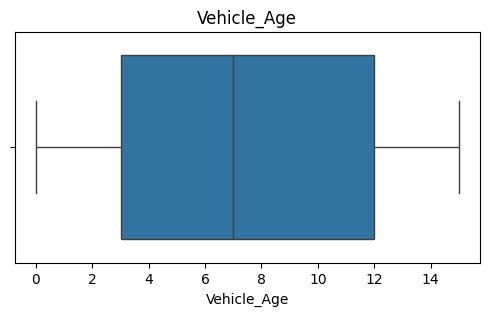

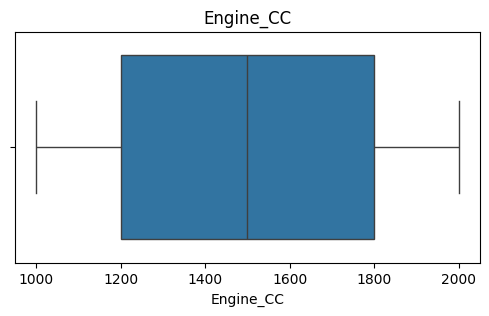

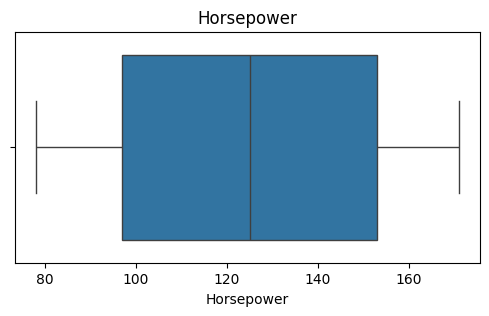

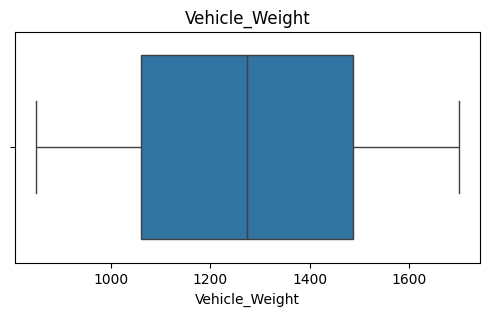

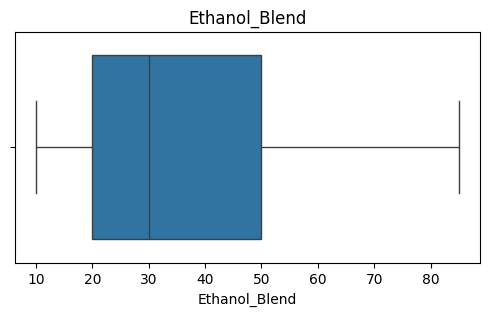

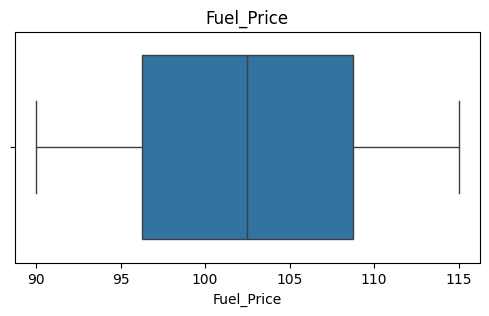

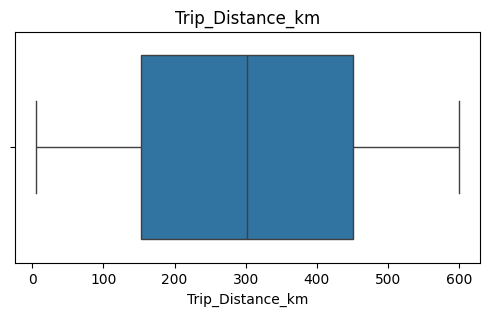

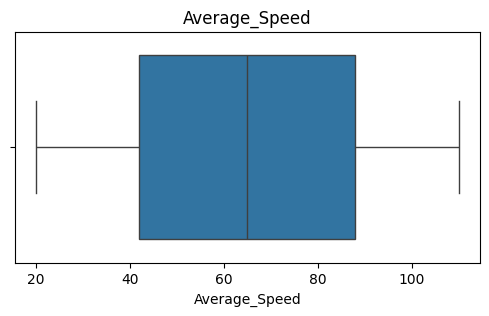

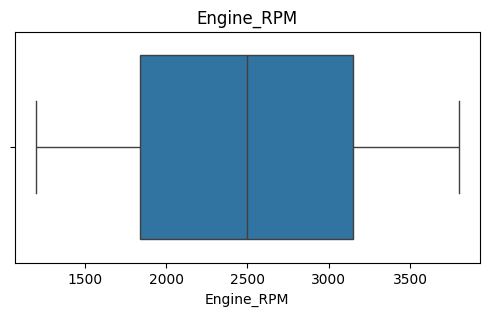

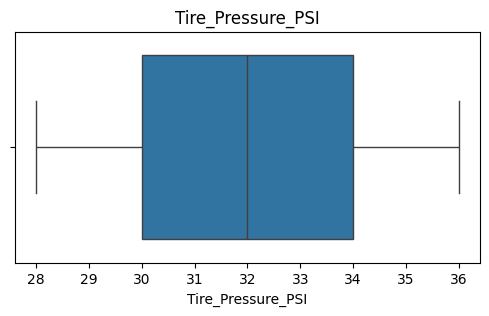

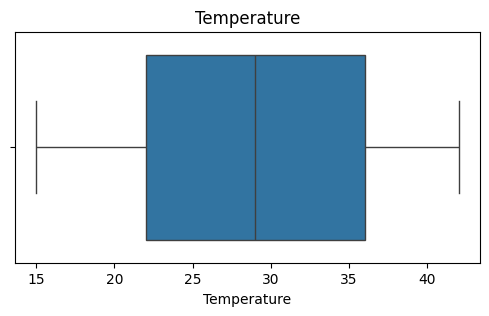

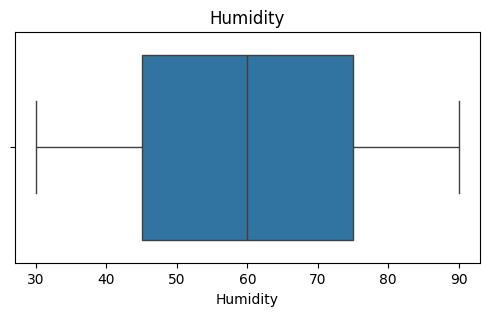

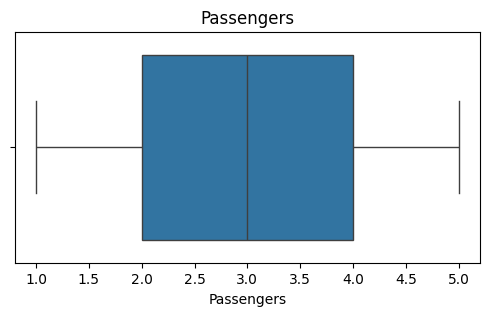

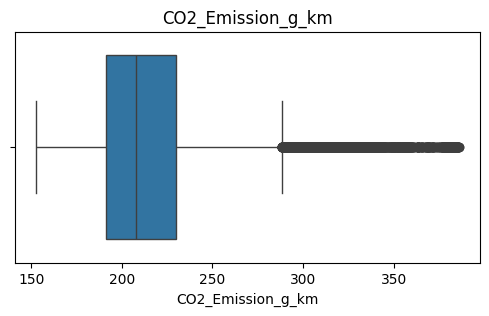

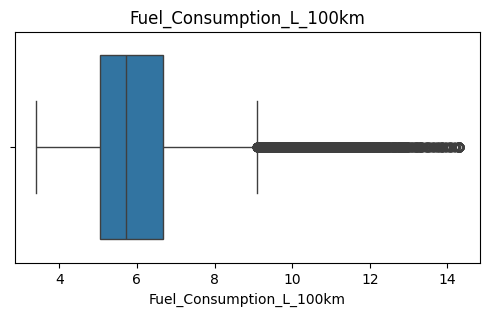

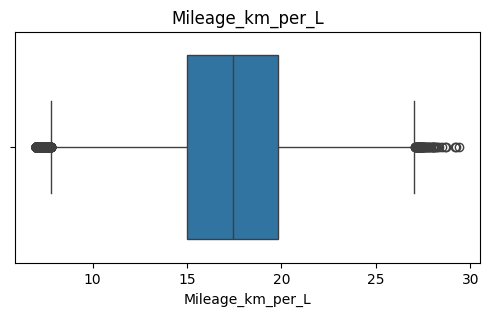

In [16]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

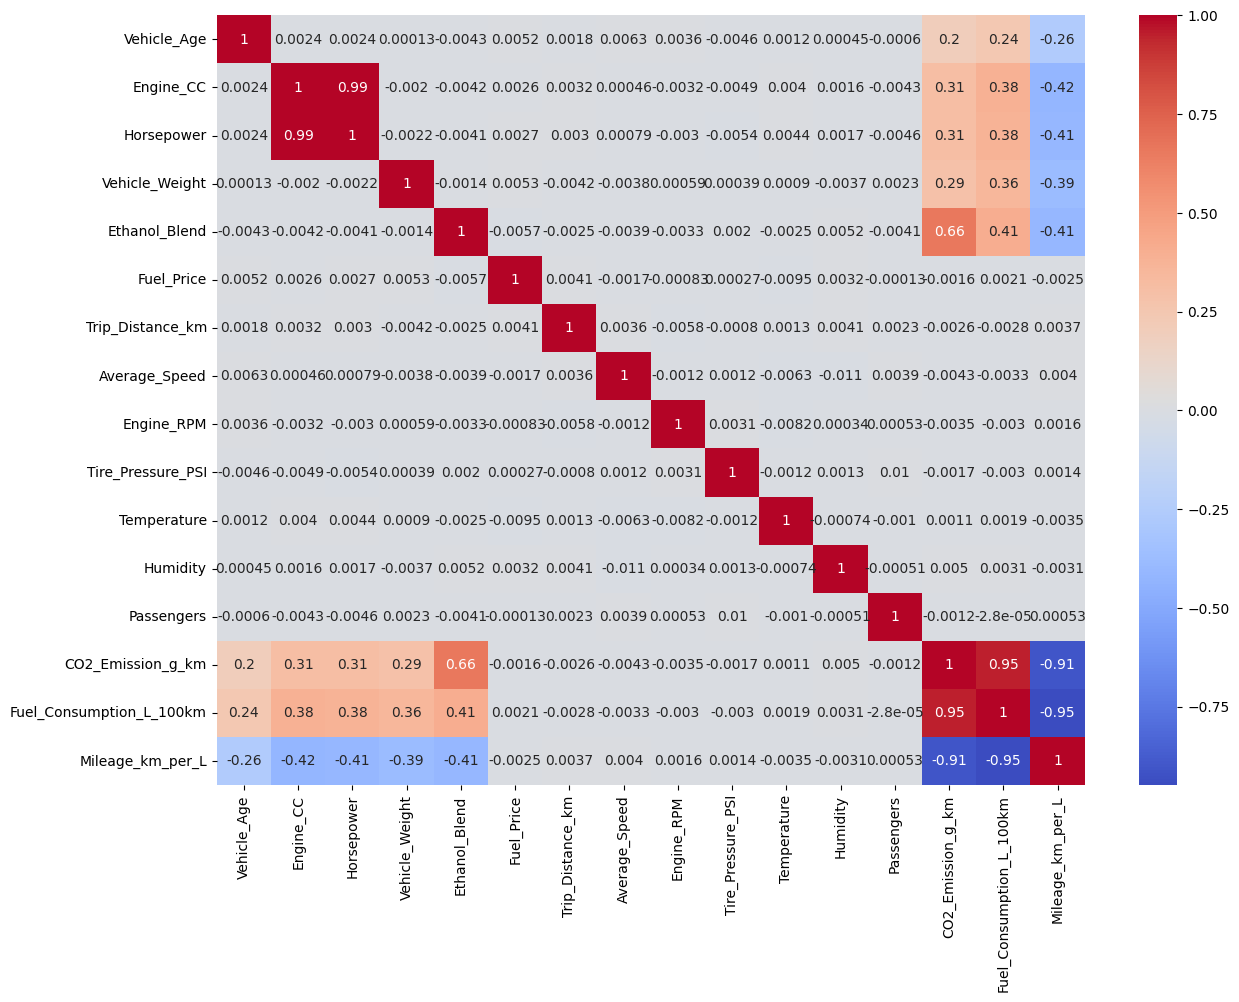

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [18]:
validation_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

validation_report

,Data Type,Missing Values,Unique Values
Vehicle_ID,str,1,64302
Manufacturer,str,2,5
Model,str,1,8
Vehicle_Age,float64,295,16
Engine_CC,float64,1,5
Horsepower,float64,4,55
Vehicle_Weight,float64,2,851
Transmission,str,3,2
Fuel_Type,str,1,1
Ethanol_Blend,float64,1,5


In [19]:
validation_report.to_csv(
    r"D:\Vehicle_Mileage_Project\data\processed\validation_report.csv",
    index=True
)

In [20]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

Duplicate Percentage : 0.84%


In [21]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 64849 entries, 0 to 64848
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Vehicle_ID                64848 non-null  str    
 1   Manufacturer              64847 non-null  str    
 2   Model                     64848 non-null  str    
 3   Vehicle_Age               64554 non-null  float64
 4   Engine_CC                 64848 non-null  float64
 5   Horsepower                64845 non-null  float64
 6   Vehicle_Weight            64847 non-null  float64
 7   Transmission              64846 non-null  str    
 8   Fuel_Type                 64848 non-null  str    
 9   Ethanol_Blend             64848 non-null  float64
 10  Fuel_Price                64848 non-null  float64
 11  Trip_Distance_km          64846 non-null  float64
 12  Average_Speed             64846 non-null  float64
 13  Engine_RPM                64844 non-null  float64
 14  Tire_Pressure_PSI